In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [25]:
loan_known_df=data.loc[data['Loan_Status'].isin(['closed','active','default'])]

In [29]:
loan_known_df.head()

,Loan_ID,Customer_ID,Loan_Type,Sanction_Amount,Interest_Rate,Tenure_Months,EMI,Loan_Status,Branch
1,LOAN77532,CUST7725,Auto Loan,455031,13.53,60,10477.23,closed,kochi
4,LOAN23871,CUST2308,Personal Loan,6208981,7.31,60,123855.41,active,Chennai
5,LOAN52689,CUST9027,Home Loan,1180431,13.95,180,15680.65,active,CHENNAI
6,LOAN56908,CUST4780,Home Loan,5652235,11.77%,60,125074.89,active,CALICUT
7,LOAN69584,CUST1003,Auto Loan,7285879,12.04,240,80427.07,default,KOCHI


In [31]:
loan_known_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 1 to 4999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          3677 non-null   object 
 1   Customer_ID      3677 non-null   object 
 2   Loan_Type        3677 non-null   object 
 3   Sanction_Amount  3677 non-null   int64  
 4   Interest_Rate    3677 non-null   object 
 5   Tenure_Months    3677 non-null   int64  
 6   EMI              3677 non-null   float64
 7   Loan_Status      3677 non-null   object 
 8   Branch           3677 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 287.3+ KB


In [35]:
print(loan_known_df['Loan_Status'].value_counts())

Loan_Status
active     2059
closed     1047
default     571
Name: count, dtype: int64


In [91]:
default_rate=(571/5000)*100
print(default_rate)

11.42


In [1]:
active_rate = (2059/5000)*100
c_rate = (1047/5000)*100
print(active_rate)
print(c_rate)

41.18
20.94


In [39]:
loan_known_df.to_csv('E:\Data Analysis\Project\Loan\Loan known.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Admin\AppData\Local\Temp\ipykernel_19212\133365334.py:1: SyntaxWarning: invalid escape sequence '\D'
  loan_known_df.to_csv('E:\Data Analysis\Project\Loan\Loan known.csv')


In [7]:
#Remove % from interest rate
fact_df['interest_rate']=fact_df['interest_rate'].str.replace('%','',regex=False).str.strip()

#convert dtype into float
fact_df['interest_rate']=pd.to_numeric(fact_df['interest_rate'],errors='coerce')

AUC score: 0.47249885531135527


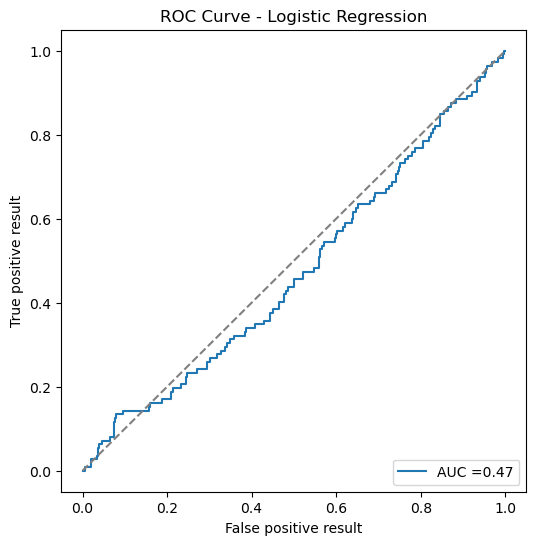

In [21]:
# ROC curve and AUC score
from sklearn.metrics import roc_curve, roc_auc_score

#Get Predicted Probability for the positive class(default)
y_prob=model1.predict_proba(x_test)[:,1]

#compute ROC curve 
fpr, tpr, thresholds=roc_curve(y_test,y_prob)

#compute AUC
Auc_score=roc_auc_score(y_test,y_prob)
print('AUC score:', Auc_score)

#plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC ={Auc_score:.2f}')
plt.plot([0,1],[0,1], linestyle='--', color='gray')

plt.xlabel('False positive result')
plt.ylabel('True positive result')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

In [11]:
#oversample default with SMOTE
from imblearn.over_sampling import SMOTE

#apply SMOTE
smote=SMOTE(random_state=42)
x_resampled,y_resampled = smote.fit_resample(x_scaled,y)

#Train Losgistic regression on balanced data
#model2=LogisticRegression(max_iter=1000)
#x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2)
#model2.fit(x_train,y_train)

In [17]:
#accuracy and precison of model after applying SMOTE

y_pred=model2.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)
print('accuracy score:',accuracy)

cm=confusion_matrix(y_test,y_pred)
print('confusion matrix:\n',cm)

report=classification_report(y_test,y_pred)
print('classification report:\n',report)

accuracy score: 0.503620273531778
confusion matrix:
 [[304 296]
 [321 322]]
classification report:
               precision    recall  f1-score   support

           0       0.49      0.51      0.50       600
           1       0.52      0.50      0.51       643

    accuracy                           0.50      1243
   macro avg       0.50      0.50      0.50      1243
weighted avg       0.50      0.50      0.50      1243



In [21]:
coeff=pd.DataFrame({'feature':x.columns,'coefficients':np.exp(model2.coef_[0])})
print(coeff)

            feature  coefficients
0               emi      1.038516
1            income      1.026519
2     interest_rate      0.967698
3  emi_income_ratio      0.984671
4      credit_score      1.130976


In [19]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

#train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2)
#Train the random forest model with  balanced class weights

rf_model=RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42)

rf_model.fit(x_train,y_train)

#prediction

y_pred=rf_model.predict(x_test)



In [21]:
#Evaluation

print('accuracy:',accuracy_score(y_test,y_pred))
print('confusion matrix:\n',confusion_matrix(y_test,y_pred))
print('classification report:\n',classification_report(y_test,y_pred))

accuracy: 0.8238133547868061
confusion matrix:
 [[506 132]
 [ 87 518]]
classification report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.82       638
           1       0.80      0.86      0.83       605

    accuracy                           0.82      1243
   macro avg       0.83      0.82      0.82      1243
weighted avg       0.83      0.82      0.82      1243



In [23]:
#feature importances

importances=rf_model.feature_importances_
for feat, imp in zip(x.columns,importances):
    print(f'{feat}: {imp:.3f}')

emi: 0.184
income: 0.201
interest_rate: 0.217
emi_income_ratio: 0.183
credit_score: 0.215


Borrower risk (pricing and interest rate) and default factors

In [85]:
data2=pd.read_csv('Borrower_risk_updated.csv')
data2['Branch']=data2['Branch'].str.strip()

In [87]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          5000 non-null   object 
 1   Customer_ID      5000 non-null   object 
 2   Loan_Type        5000 non-null   object 
 3   Sanction_Amount  5000 non-null   int64  
 4   Interest_Rate    5000 non-null   float64
 5   Tenure_Months    5000 non-null   int64  
 6   EMI              5000 non-null   float64
 7   Loan_Status      5000 non-null   object 
 8   Branch           5000 non-null   object 
 9   Income           5000 non-null   int64  
 10  Credit_score     5000 non-null   int64  
 11  Monthly_Income   5000 non-null   float64
 12  DTI              5000 non-null   float64
 13  LTI              5000 non-null   float64
 14  Emi_burden       5000 non-null   float64
 15  Interest_burden  5000 non-null   float64
 16  Credit_risk      5000 non-null   object 
dtypes: float64(7),

In [33]:
data2.head()

,Loan_ID,Customer_ID,Loan_Type,Sanction_Amount,Interest_Rate,Tenure_Months,EMI,Loan_Status,Branch,Income,Credit_score,Monthly_Income,DTI,LTI,Emi_burden,Interest_burden,Credit_risk
0,LOAN98932,CUST1001,Home Loan,1488621,8.69,240,13098.17,active,chennai,4467228,660,372269.00,3.52,0.33,0.70,2.90,Medium Risk
1,LOAN69584,CUST1003,Auto Loan,7285879,12.04,240,80427.07,default,kochi,3508627,824,292385.58,27.51,2.08,5.50,25.00,Low Risk
2,LOAN22318,CUST1004,Personal Loan,9482189,9.99,36,305919.05,active,calicut,3740188,558,311682.33,98.15,2.54,2.94,25.33,High Risk
3,LOAN42192,CUST1006,Auto Loan,5356368,8.86,180,53882.66,closed,trivandrum,1890507,837,157542.25,440.36,6.62,5.13,25.10,Low Risk
4,LOAN26694,CUST1006,Business Loan,7159184,13.13,12,639875.54,unknown,kochi,1890507,837,157542.25,440.36,6.62,4.06,49.72,Low Risk


In [5]:
#logistic regression(simple) + SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve


#preparing datasets for logistic model
df=data2[['Credit_score','DTI','LTI','Emi_burden','Interest_burden']]

df=df.fillna(0)

X=df.copy()
y=(data2['Loan_Status']=='default').astype(int)

scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

#smote resambling
smote=SMOTE(random_state=42)
x_resambled,y_resambled = smote.fit_resample(x_scaled,y)
#Train-test split
x_train, x_test, y_train, y_test = train_test_split(x_resambled,y_resambled,test_size=0.2,stratify=y_resambled,random_state=42)


#model with regularization and class weight
model=LogisticRegression(class_weight='balanced',max_iter=1000)

model.fit(x_train,y_train)


y_pred=model.predict(x_test)

print('accuracy_score:',accuracy_score(y_test,y_pred))
print('Confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))

accuracy_score: 0.5282167042889391
Confusion_matrix: [[399 487]
 [349 537]]
classification_report:               precision    recall  f1-score   support

           0       0.53      0.45      0.49       886
           1       0.52      0.61      0.56       886

    accuracy                           0.53      1772
   macro avg       0.53      0.53      0.53      1772
weighted avg       0.53      0.53      0.53      1772



In [9]:
coeff=pd.DataFrame({'feature':X.columns,'coefficients':model.coef_[0]})
print(coeff)

           feature  coefficients
0     Credit_score      0.055861
1              DTI      0.119406
2              LTI     -0.123405
3       Emi_burden      0.291029
4  Interest_burden     -0.325720


In [5]:
#Random Forest(simple) + SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve


#preparing datasets for logistic model
df=data2[['Credit_score','DTI','LTI','Emi_burden','Interest_burden']]

df=df.fillna(0)

X=df.copy()
y=(data2['Loan_Status']=='default').astype(int)

data2['default_flag']=y
#preprocessing
#cat_features=['Credit_risk']
#num_features=['DTI','LTI','Emi_burden','Interest_burden']

#cat_transformer=Pipeline([
#    ('ohe',OneHotEncoder(handle_unknown='ignore'))
#])

#num_transformer=Pipeline([
#    ('scaler',StandardScaler())
#])

#preprocessor=ColumnTransformer([
#    ('num',num_transformer,num_features),
#    ('cat',cat_transformer,cat_features)
#])
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

smote=SMOTE(random_state=42)
x_resampled,y_resampled = smote.fit_resample(x_scaled,y)
#Train-test split
x_train, x_test, y_train, y_test = train_test_split(x_resampled,y_resampled,test_size=0.2,stratify=y_resampled,random_state=42)

rf=RandomForestClassifier(random_state=42,n_jobs=1,class_weight='balanced',n_estimators=200,max_depth=None)
#model with regularization and class weight

#pipe = ImbPipeline([
#    ('prepoc',preprocessor),
#    ('smote',SMOTE(random_state=42)),
#    ('clf',rf)
#])

#param_grid={
#    'clf__n_estimators':[200,500],
#    'clf__max_depth':[6,12,20],
#}


#grid=GridSearchCV(pipe,param_grid,cv=5,verbose=1,n_jobs=1,scoring='f1')

rf.fit(x_train,y_train)

y_pred=rf.predict(x_test)

print('accuracy_score:',accuracy_score(y_test,y_pred))
print('Confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))

data2['PD']=rf.predict_proba(X)[:,1]

accuracy_score: 0.8414221218961625
Confusion_matrix: [[732 154]
 [127 759]]
classification_report:               precision    recall  f1-score   support

           0       0.85      0.83      0.84       886
           1       0.83      0.86      0.84       886

    accuracy                           0.84      1772
   macro avg       0.84      0.84      0.84      1772
weighted avg       0.84      0.84      0.84      1772



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [23]:
#correlation result undersampled model
model=best_model.named_steps['clf']

coeff=pd.DataFrame({'Features':X.columns,'coefficients':model.coef_[0],'Odd rato':np.exp(model.coef_[0])})
print(coeff)

          Features  coefficients  Odd rato
0     Credit_score      0.102805  1.108275
1           Income      0.015529  1.015650
2  Sanction_Amount     -0.011572  0.988495
3    Interest_Rate      0.020810  1.021028
4    Tenure_Months     -0.011797  0.988273


In [11]:
importances=rf.feature_importances_
fi=pd.DataFrame({'feature':X.columns,'Importance': importances})
fi=fi.sort_values('Importance',ascending=False)

print(fi)

#correlation matrix
data2['default_flag']= y
cor_features= data2[['Credit_score','Interest_Rate','DTI','LTI','Emi_burden','Interest_burden','default_flag','PD']]

corr_matrix=cor_features.corr(method='pearson')
print(corr_matrix)



           feature  Importance
0     Credit_score    0.224144
1              DTI    0.200792
4  Interest_burden    0.193637
2              LTI    0.192402
3       Emi_burden    0.189025
                 Credit_score  Interest_Rate       DTI       LTI  Emi_burden  \
Credit_score         1.000000       0.001140 -0.056146 -0.075258   -0.110019   
Interest_Rate        0.001140       1.000000  0.024918  0.002711    0.048282   
DTI                 -0.056146       0.024918  1.000000  0.790954    0.497524   
LTI                 -0.075258       0.002711  0.790954  1.000000    0.761643   
Emi_burden          -0.110019       0.048282  0.497524  0.761643    1.000000   
Interest_burden     -0.123089       0.122410  0.672298  0.796110    0.922676   
default_flag         0.024950       0.001114  0.001565 -0.002336   -0.004306   
PD                  -0.050765       0.028867  0.346553  0.399059    0.301333   

                 Interest_burden  default_flag        PD  
Credit_score           -0.123089  

Auc_score: 0.9243391049126365


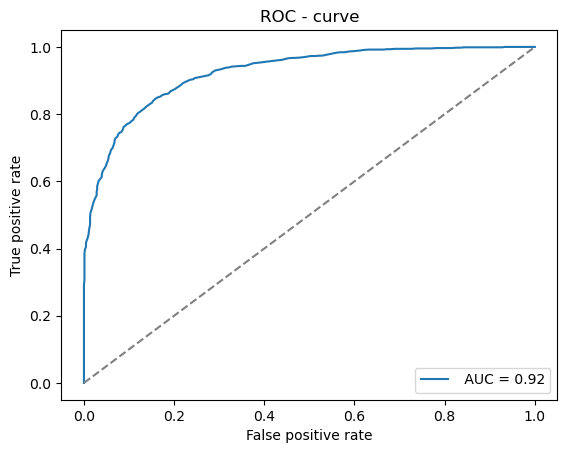

In [17]:
#ROC and AUC
from sklearn.metrics import roc_curve, roc_auc_score

#predicted probabilities of positive class
y_prob=rf.predict_proba(x_test)[:,1]

#compute roc_curve
fpr , tpr, threshold = roc_curve(y_test,y_prob)

#compute auc score
auc_score = roc_auc_score(y_test,y_prob)

print('Auc_score:',auc_score)

plt.plot(fpr,tpr,label=f' AUC = {auc_score:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color='grey')

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC - curve')
plt.legend(loc='lower right')
plt.show()

In [89]:
#segmentation and anomaly detection

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df3=data2[['PD','Sanction_Amount','Income','DTI','Credit_score','Emi_burden','Interest_Rate','Branch','Loan_Type']]

X=df3[['PD','Sanction_Amount','Income','DTI','Credit_score','Emi_burden']].values
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)


#fit kmeans

kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
labels=kmeans.fit_predict(x_scaled)
data2['cluster_raw']=labels


#Order Cluster with mean of PD

cluster_order = data2.groupby('cluster_raw')['PD'].mean().sort_values().index.tolist()

#Map raw labels to cluster order

label_map = {raw : rank for rank, raw in enumerate(cluster_order)} 

data2['Clusters']=data2['cluster_raw'].map(label_map)

#Summary table of clusters

Summary = data2.groupby('Clusters').agg(
    count = ('PD','size'),
    mean_PD = ('PD','mean'),
    mean_loan_amt = ('Sanction_Amount','mean'),
    mean_dti = ('DTI','mean'),
    mean_int_rate = ('Interest_Rate','mean'),
    mean_cred_sc = ('Credit_score','mean'),
    mean_income = ('Income','mean')
).reset_index().sort_values('Clusters')

print('Overall Summary of clusters:',Summary)


#Branch and loan type

branch_table = data2.groupby(['Branch','Clusters']).agg(
    count = ('PD','size'),
    mean_int_rate = ('Interest_Rate','mean'),
    mean_PD = ('PD','mean')
).reset_index()

print('Branch level summary of cluster',branch_table)

Loantype_table = data2.groupby(['Loan_Type','Clusters']).agg(
    count = ('PD','size'),
    mean_int_rate = ('Interest_Rate','mean'),
    mean_PD = ('PD','mean')
).reset_index()

print('Loant type level summary of clusters:', Loantype_table)



#Visualisation

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.scatterplot(data=data2, x = 'Sanction_Amount', y = 'PD', hue='Clusters',palette='viridis',alpha=0.7)
plt.title('PD vs Loan amount by cluster')

plt.subplot(1,2,2)
sns.boxplot(data=data2, x ='Clusters', y='Interest_Rate', palette='viridis')
plt.xlabel('Cluster ( 0=low,1=medium,2=high')
plt.title('Interest rate distribution by cluster')
plt.tight_layout()
plt.show()



KeyError: "['PD'] not in index"

In [39]:
# Total loan amount exposed to different clusters
loan_exposure_cluster = df.groupby('Clusters')['Sanction_Amount'].sum()
print(loan_exposure_cluster)

Clusters
0    18457508730
1      433575135
2     6512248776
Name: Sanction_Amount, dtype: int64


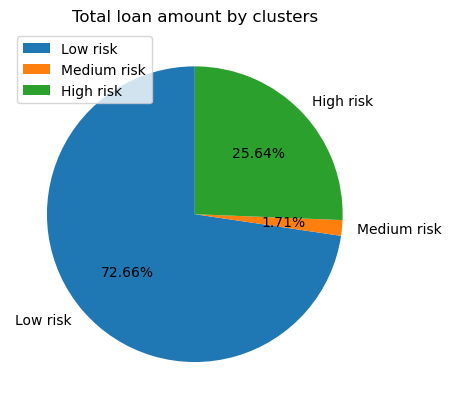

In [51]:
label={'Low risk':'0','Medium risk':'1','High risk':'2'}
plt.pie(loan_exposure_cluster,autopct='%1.2f%%',labels=label,startangle=90)
plt.title('Total loan amount by clusters')
plt.legend()
plt.show()

In [59]:
#loan type exposed to high risk clusters
num_loan_type = df.groupby('Loan_Type')['Loan_uid'].count()
print(num_loan_type)

loan_type_risk = df.groupby(['Loan_Type','Clusters'])['Loan_uid'].count()
print(loan_type_risk)

Loan_Type
Auto Loan        1218
Business Loan    1297
Home Loan        1266
Personal Loan    1219
Name: Loan_uid, dtype: int64
Loan_Type      Clusters
Auto Loan      0            952
               1             10
               2            256
Business Loan  0           1007
               1             13
               2            277
Home Loan      0            982
               1             19
               2            265
Personal Loan  0            958
               1             18
               2            243
Name: Loan_uid, dtype: int64


Opportunity for Better risk-based pricing:
~ Higher PD -> Higher spread 
~ Lower PD  -> preferencial pricing
~ Better credit score -> lower risk
Improves:
~ Portfolio profitability
~ capital efficiency
~ Risk-adjusted pricing fairness

In [21]:
data2.to_csv('E:\Data Analysis\Project\Loan\Loan_risk.csv',index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Admin\AppData\Local\Temp\ipykernel_15820\1734705142.py:1: SyntaxWarning: invalid escape sequence '\D'
  data2.to_csv('E:\Data Analysis\Project\Loan\Loan_risk.csv',index=False)


Loan segments with early signs of stress

In [37]:
df=pd.read_csv('Loan_risk.csv')
#df.head()

In [25]:
non_default=df[df['Loan_Status'].isin(['active','unknown'])].reset_index(drop=True)
non_default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3382 entries, 0 to 3381
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          3382 non-null   object 
 1   Customer_ID      3382 non-null   object 
 2   Loan_Type        3382 non-null   object 
 3   Sanction_Amount  3382 non-null   int64  
 4   Interest_Rate    3382 non-null   float64
 5   Tenure_Months    3382 non-null   int64  
 6   EMI              3382 non-null   float64
 7   Loan_Status      3382 non-null   object 
 8   Branch           3382 non-null   object 
 9   Income           3382 non-null   int64  
 10  Credit_score     3382 non-null   int64  
 11  Monthly_Income   3382 non-null   float64
 12  DTI              3382 non-null   float64
 13  LTI              3382 non-null   float64
 14  Emi_burden       3382 non-null   float64
 15  Interest_burden  3382 non-null   float64
 16  Credit_risk      3382 non-null   object 
 17  default_flag  

In [7]:
non_default[['PD','DTI']].describe()

,PD,DTI
count,3382.000000,3382.000000
mean,0.101467,199.195470
std,0.086016,359.870129
min,0.020000,0.420000
25%,0.035000,46.372500
50%,0.060000,106.415000
75%,0.150000,213.850000
max,0.420000,7490.900000


In [81]:
Stress_segment = non_default[
     (non_default['PD'] >= 0.15) &
     (non_default['DTI'] >= 36)
].reset_index(drop=True)

#Stress_segment.head(20)

In [79]:
stress_loan=Stress_segment.groupby(['Branch','Loan_Type']).agg(
    loan_count = ('Loan_uid','count')
)
print(stress_loan)

branch_stress=Stress_segment.groupby('Branch')['Loan_uid'].count()
print(branch_stress)

loan_type_stress=Stress_segment.groupby('Loan_Type')['Loan_uid'].count()
print(loan_type_stress)


                          loan_count
Branch     Loan_Type                
calicut    Auto Loan              32
           Business Loan          38
           Home Loan              33
           Personal Loan          31
chennai    Auto Loan              36
           Business Loan          27
           Home Loan              28
           Personal Loan          26
kochi      Auto Loan              35
           Business Loan          28
           Home Loan              29
           Personal Loan          29
trivandrum Auto Loan              26
           Business Loan          45
           Home Loan              29
           Personal Loan          18
Branch
calicut       134
chennai       117
kochi         121
trivandrum    118
Name: Loan_uid, dtype: int64
Loan_Type
Auto Loan        129
Business Loan    138
Home Loan        119
Personal Loan    104
Name: Loan_uid, dtype: int64


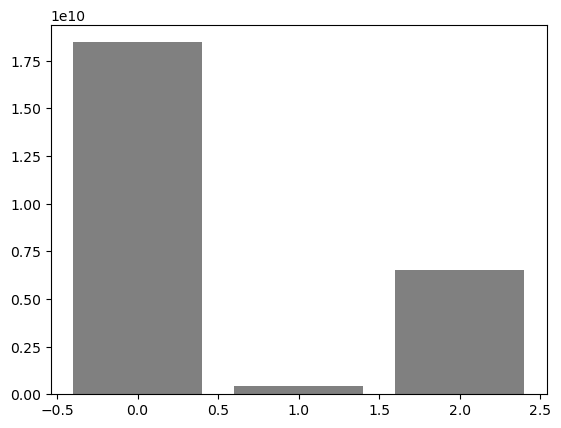

In [67]:
plt.bar(loan_amount_exp_risk['Clusters'],loan_amount_exp_risk['Sanction_Amount'],color='grey')
plt.show()